# VectorFFT Benchmark Plots
VkFFT-style scatter plots for performance (GFLOP/s) and accuracy (roundtrip error).

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

plt.rcParams.update({
    'figure.figsize': (14, 7),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 120,
})

In [ ]:
# Load + prep  (adapted to the new CSV schema:
#   N,K,plan,path,vfft_ns,mkl_ns,vfft_gflops,ratio_vs_mkl,rt_err)
# This cell also DEFINES the visual identity (VFFT_COLOR/MKL_COLOR/cat_markers)
# and the derived columns (category, mkl_gflops) that the plot cells below need.
import os

candidates = ['.', '../benches', '../../build_tuned/benches', 'csv', '../csv']
base = None
for d in candidates:
    if os.path.exists(os.path.join(d, 'vfft_perf_tuned_1d.csv')):
        base = d; break
if base is None:
    raise FileNotFoundError(f"vfft_perf_tuned_1d.csv not found. CWD={os.getcwd()} searched={candidates}")
print(f'Loading from: {os.path.abspath(base)}')
perf = pd.read_csv(os.path.join(base, 'vfft_perf_tuned_1d.csv'))

# --- derived columns the plots expect ---
perf['mkl_gflops'] = perf['vfft_gflops'] / perf['ratio_vs_mkl']

def _categorize(row):
    N = int(row['N']); path = str(row['path']).lower()
    if 'blue'  in path: return 'bluestein'
    if 'rader' in path: return 'rader'
    n = N; primes = {}
    d = 2
    while d * d <= n:
        while n % d == 0: primes[d] = primes.get(d, 0) + 1; n //= d
        d += 1
    if n > 1: primes[n] = primes.get(n, 0) + 1
    ps = set(primes)
    if ps == {2}:                       return 'small' if N <= 128 else 'pow2'
    if len(ps) == 1 and ps <= {3,5,7}:  return 'prime_pow'
    if len(ps) == 1 and ps <= {11,13}:  return 'genfft'
    if 2 not in ps:                     return 'odd_comp'
    return 'mixed_deep' if len(ps) >= 3 else 'composite'

perf['category'] = perf.apply(_categorize, axis=1)

# accuracy frame: the roundtrip error now lives in the perf CSV (rt_err column)
acc = perf[['N', 'K', 'rt_err', 'category']].rename(columns={'rt_err': 'roundtrip_err'})

# --- visual identity (referenced by the plot cells; define once here) ---
VFFT_COLOR = '#1f77b4'   # blue
MKL_COLOR  = '#d62728'   # red
cat_markers = {
    'small':      {'marker': 'o', 'label': 'pow2 small (8-128)'},
    'pow2':       {'marker': 's', 'label': 'pow2 (256-131072)'},
    'composite':  {'marker': '^', 'label': 'composite'},
    'prime_pow':  {'marker': 'D', 'label': 'prime powers (3,5,7)'},
    'genfft':     {'marker': 'P', 'label': 'genfft (R=11,13)'},
    'rader':      {'marker': 'X', 'label': 'Rader primes'},
    'odd_comp':   {'marker': 'v', 'label': 'odd composites'},
    'mixed_deep': {'marker': '*', 'label': 'mixed deep'},
    'bluestein':  {'marker': 'h', 'label': 'Bluestein primes'},
}
print(f'Performance: {len(perf)} rows | category counts:')
print(perf['category'].value_counts().to_string())
perf.head()


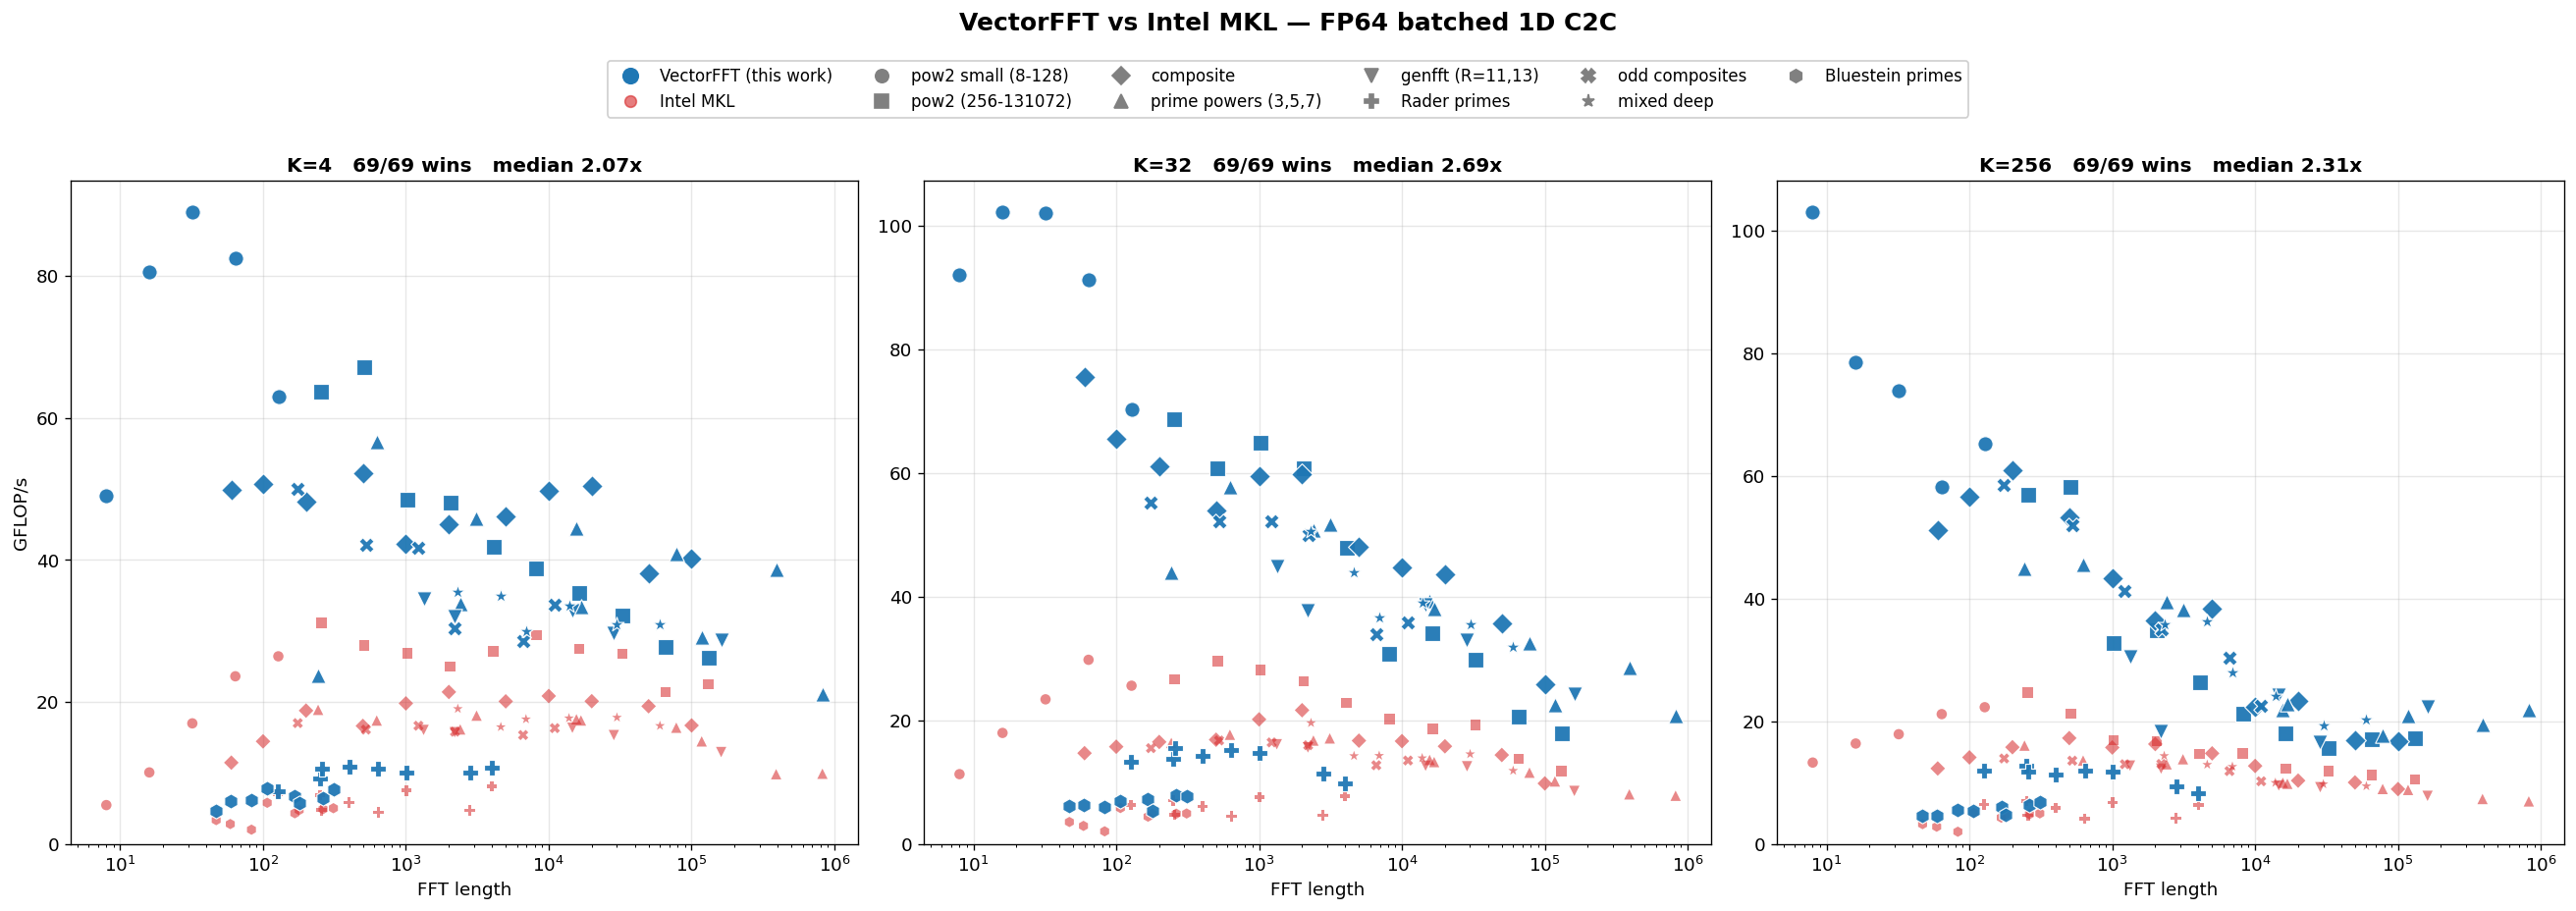

Saved: vfft_throughput_1d.png


In [94]:
# Per-K performance plot — apples-to-apples GFlops within each K.
# VFFT markers are bigger with a white edge so they always sit visibly
# on top of MKL even when ratios are tight (no "red on top of blue" illusion).

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for idx, K in enumerate([4, 32, 256]):
    ax = axes[idx]
    sub = perf[perf["K"] == K].copy()

    # MKL first (red, small, dim — background)
    for cat, style in cat_markers.items():
        d = sub[sub["category"] == cat]
        if len(d) == 0 or d["mkl_gflops"].sum() == 0: continue
        ax.scatter(d["N"], d["mkl_gflops"], c=MKL_COLOR,
                   marker=style["marker"], s=40, alpha=0.55,
                   edgecolors="none", zorder=2)

    # VFFT on top (blue, larger, vivid, white edge — always stands out)
    for cat, style in cat_markers.items():
        d = sub[sub["category"] == cat]
        if len(d) == 0: continue
        ax.scatter(d["N"], d["vfft_gflops"], c=VFFT_COLOR,
                   marker=style["marker"], s=85, alpha=0.95,
                   edgecolors="white", linewidth=0.7, zorder=4)

    ax.set_xscale("log")
    ax.set_xlabel("FFT length")
    if idx == 0: ax.set_ylabel("GFLOP/s")
    wins = (sub["ratio_vs_mkl"] > 1.0).sum()
    med = sub["ratio_vs_mkl"].median()
    ax.set_title(f"K={K}   {wins}/{len(sub)} wins   median {med:.2f}x",
                 fontsize=12, fontweight="bold")
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)

from matplotlib.lines import Line2D
lib_legend = [
    Line2D([0],[0], marker="o", color=VFFT_COLOR, markersize=11,
           markeredgecolor="white", markeredgewidth=0.7,
           linestyle="None", label="VectorFFT (this work)"),
    Line2D([0],[0], marker="o", color=MKL_COLOR, markersize=7,
           linestyle="None", alpha=0.6, label="Intel MKL"),
]
cat_legend = [Line2D([0],[0], marker=s["marker"], color="gray",
                     markersize=8, linestyle="None", label=s["label"])
              for s in cat_markers.values()]
fig.legend(handles=lib_legend + cat_legend, loc="upper center", ncol=6,
           bbox_to_anchor=(0.5, 1.05), fontsize=10, framealpha=0.95)
fig.suptitle("VectorFFT vs Intel MKL — FP64 batched 1D C2C",
             fontsize=15, fontweight="bold", y=1.10)

plt.tight_layout()
plt.savefig("vfft_throughput_1d.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: vfft_throughput_1d.png")


In [ ]:
# Speedup ratio plot — VFFT/MKL across all sizes and K values.
# Header text shows per-category and total stats (cells, median, range).

# Compute stats per category and overall
cat_order = ['small','pow2','composite','prime_pow','genfft','rader',
             'odd_comp','mixed_deep','bluestein']
cat_label = {
    'small':'pow2 small (8-128)', 'pow2':'pow2 (256-131072)',
    'composite':'composite', 'prime_pow':'prime powers (3,5,7)',
    'genfft':'genfft (R=11,13)', 'rader':'Rader primes',
    'odd_comp':'odd composites', 'mixed_deep':'mixed deep',
    'bluestein':'Bluestein primes',
}

def stats(d):
    if len(d) == 0: return None
    return {
        'n': len(d),
        'wins': int((d['ratio_vs_mkl'] > 1.0).sum()),
        'min': float(d['ratio_vs_mkl'].min()),
        'med': float(d['ratio_vs_mkl'].median()),
        'max': float(d['ratio_vs_mkl'].max()),
    }

per_cat = {c: stats(perf[perf['category'] == c]) for c in cat_order}
overall = stats(perf)

# Header text — pretty-printed table
hdr_lines = [
    f"{'Category':<22} {'Cells':>5} {'Wins':>9} {'Median':>7} {'Range':>16}",
    '-' * 62,
]
for c in cat_order:
    s = per_cat[c]
    if s is None: continue
    win_str = f"{s['wins']}/{s['n']}"
    rng = f"{s['min']:.2f}-{s['max']:.2f}x"
    hdr_lines.append(
        f"{cat_label[c]:<22} {s['n']:>5} {win_str:>9} {s['med']:>6.2f}x {rng:>16}"
    )
hdr_lines.append('-' * 62)
tot_win = f"{overall['wins']}/{overall['n']}"
tot_rng = f"{overall['min']:.2f}-{overall['max']:.2f}x"
hdr_lines.append(
    f"{'TOTAL':<22} {overall['n']:>5} {tot_win:>9} {overall['med']:>6.2f}x {tot_rng:>16}"
)
hdr = chr(10).join(hdr_lines)

fig, ax = plt.subplots(figsize=(16, 8))

for cat, style in cat_markers.items():
    d = perf[perf['category'] == cat]
    if len(d) == 0: continue
    for K, marker_size in [(4, 30), (32, 60), (256, 110)]:
        dk = d[d['K'] == K]
        if len(dk) == 0: continue
        ax.scatter(dk['N'], dk['ratio_vs_mkl'],
                   c=VFFT_COLOR, marker=style['marker'],
                   s=marker_size, alpha=0.85, edgecolors='white',
                   linewidth=0.4, zorder=3)

ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5,
           alpha=0.7, zorder=2)

ax.set_xscale('log')
ax.set_xlabel('FFT length (log)', fontsize=13)
ax.set_ylabel('Speedup vs MKL  (higher = faster)', fontsize=13)
ax.set_title('VectorFFT / MKL Speedup Ratio — All Categories',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylim(bottom=0)
ax.grid(True, which='both', alpha=0.3)

# Stats header in a monospace text box (top-left)
ax.text(0.012, 0.985, hdr, transform=ax.transAxes,
        fontsize=8.5, fontfamily='monospace',
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                  edgecolor='#333', alpha=0.95))

# Right-side legend: shapes for category, sizes for K
from matplotlib.lines import Line2D
cat_legend = [Line2D([0],[0], marker=s['marker'], color=VFFT_COLOR,
                     markersize=8, linestyle='None', label=s['label'])
              for s in cat_markers.values()]
size_legend = [
    Line2D([0],[0], marker='o', color='gray', markersize=4,
           linestyle='None', label='K=4'),
    Line2D([0],[0], marker='o', color='gray', markersize=7,
           linestyle='None', label='K=32'),
    Line2D([0],[0], marker='o', color='gray', markersize=10,
           linestyle='None', label='K=256'),
    Line2D([0],[0], color='black', linestyle='--', label='MKL parity'),
]
ax.legend(handles=cat_legend + size_legend, loc='upper right',
          fontsize=9, ncol=2, framealpha=0.95)

plt.tight_layout()
plt.savefig('vfft_speedup_vs_mkl.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: vfft_speedup_vs_mkl.png')


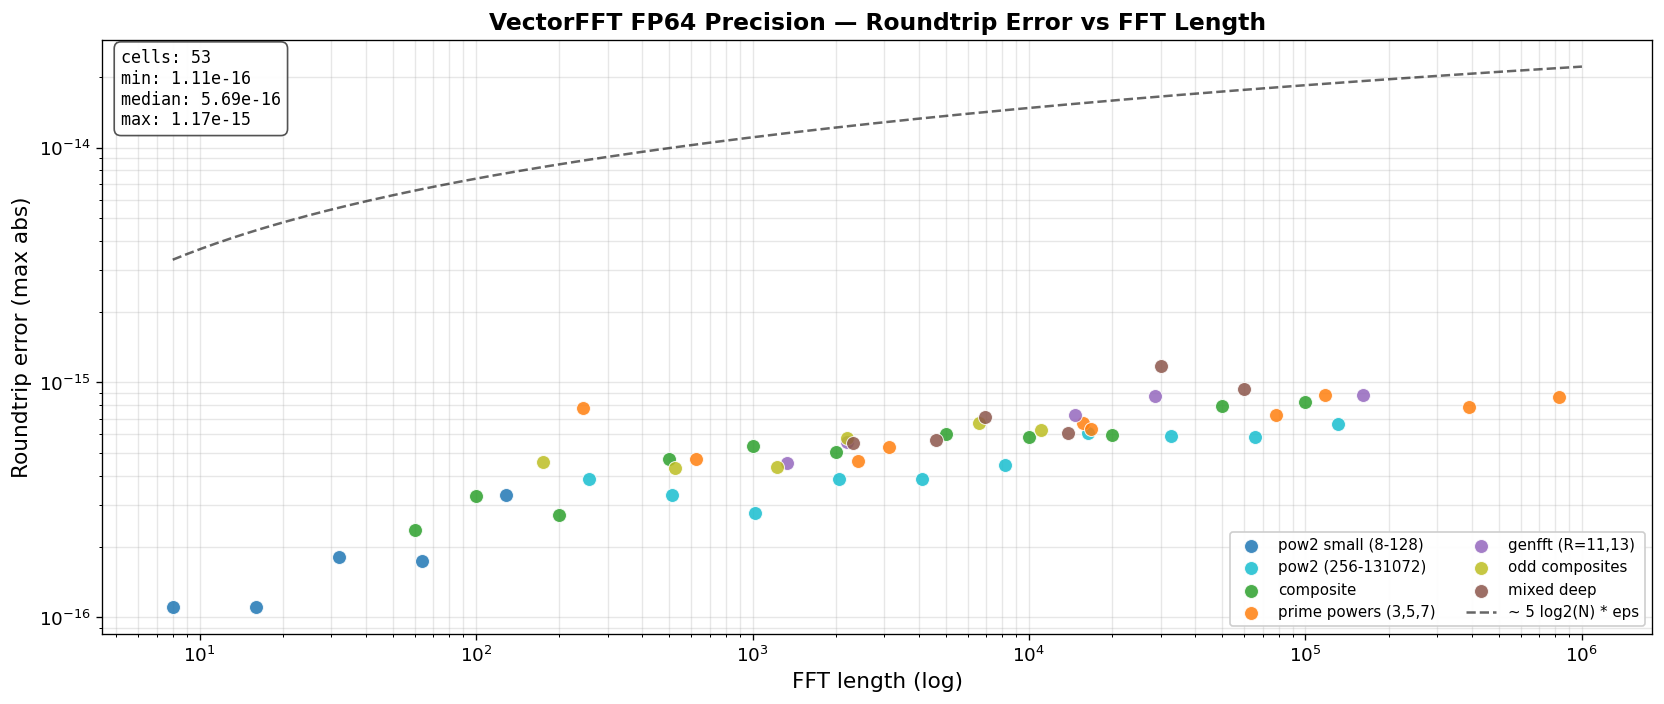

Saved: vfft_precision.png


In [96]:
# Accuracy plot — FP64 roundtrip error vs FFT length, colored by category.
# Should track ~O(log N) * eps (FP64 eps = 2.22e-16).

import numpy as np

# Reuse the same category palette from cell 6 (consistent visual identity)
cat_palette = {
    'small':      '#1f77b4', 'pow2':       '#17becf',
    'composite':  '#2ca02c', 'prime_pow':  '#ff7f0e',
    'genfft':     '#9467bd', 'rader':      '#e377c2',
    'odd_comp':   '#bcbd22', 'mixed_deep': '#8c564b',
    'bluestein':  '#d62728',
}
cat_label = {
    'small':      'pow2 small (8-128)',
    'pow2':       'pow2 (256-131072)',
    'composite':  'composite',
    'prime_pow':  'prime powers (3,5,7)',
    'genfft':     'genfft (R=11,13)',
    'rader':      'Rader primes',
    'odd_comp':   'odd composites',
    'mixed_deep': 'mixed deep',
    'bluestein':  'Bluestein primes',
}

fig, ax = plt.subplots(figsize=(14, 6))

for cat, color in cat_palette.items():
    d = acc[acc['category'] == cat]
    if len(d) == 0: continue
    ax.scatter(d['N'], d['roundtrip_err'],
               c=color, marker='o', s=70, alpha=0.85,
               edgecolors='white', linewidth=0.6,
               label=cat_label[cat], zorder=3)

# Theoretical bound ~ log2(N) * eps
eps = 2.22e-16
Ns = np.logspace(np.log10(8), np.log10(1e6), 200)
ax.plot(Ns, np.log2(Ns) * eps * 5, 'k--', alpha=0.6, linewidth=1.5,
        label="~ 5 log2(N) * eps")

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('FFT length (log)', fontsize=13)
ax.set_ylabel('Roundtrip error (max abs)', fontsize=13)
ax.set_title('VectorFFT FP64 Precision — Roundtrip Error vs FFT Length',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, ncol=2, framealpha=0.95)
ax.grid(True, which='both', alpha=0.3)

# Stats annotation
mn = acc['roundtrip_err'].min()
mx = acc['roundtrip_err'].max()
med = acc['roundtrip_err'].median()
stats = (f"cells: {len(acc)}" + chr(10) + f"min: {mn:.2e}" + chr(10) + f"median: {med:.2e}" + chr(10) + f"max: {mx:.2e}")
ax.text(0.012, 0.985, stats, transform=ax.transAxes,
        fontsize=10, fontfamily='monospace',
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#444', alpha=0.92))

plt.tight_layout()
plt.savefig('vfft_precision.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: vfft_precision.png')


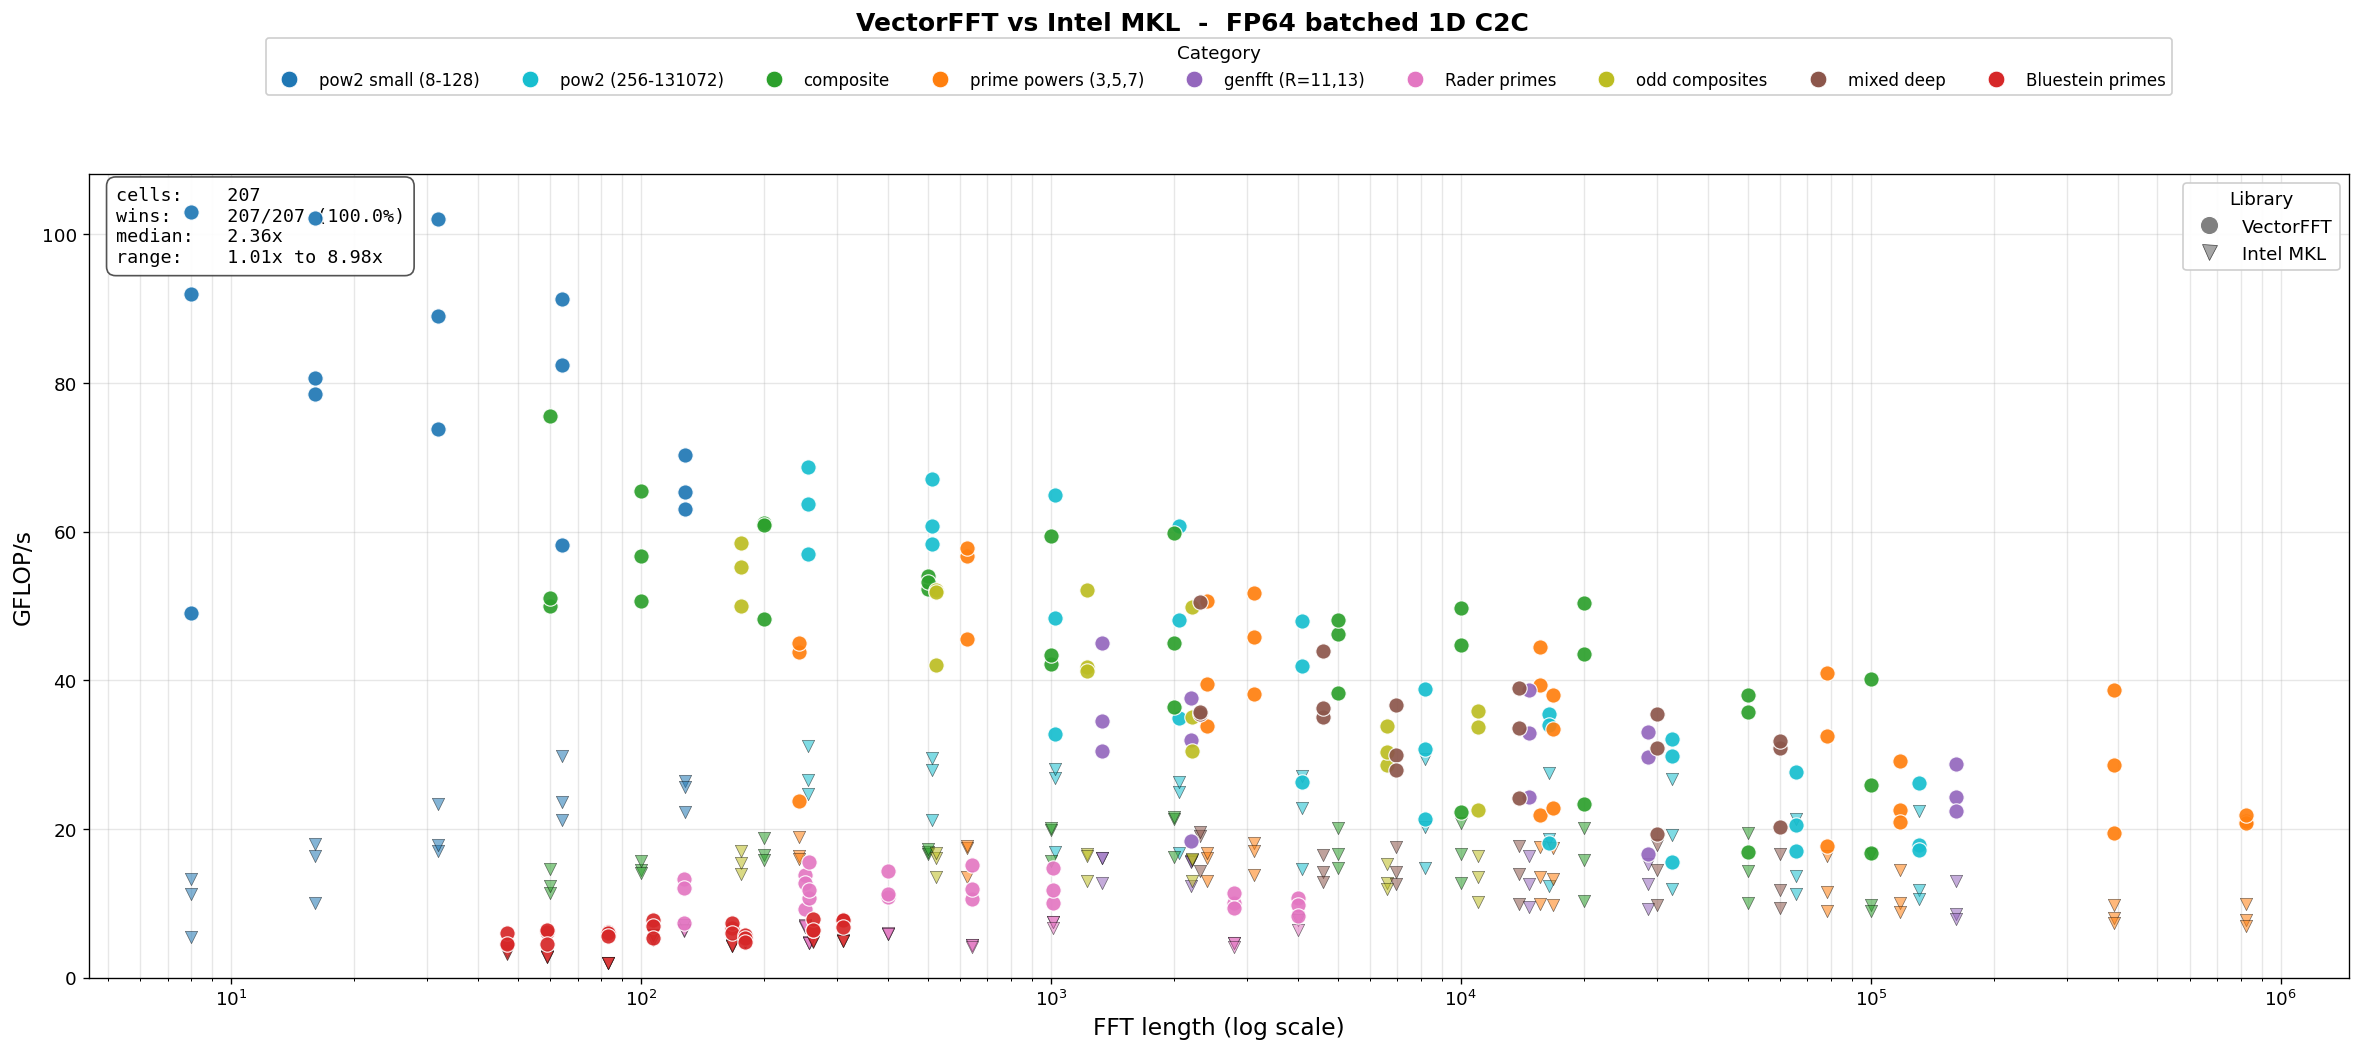

Saved: vfft_vs_mkl_overview.png


In [97]:
# All-cells overlay — VkFFT-style coloring.
# Color = category (bluestein/rader/composite/etc.)
# Marker shape = library (circle = VectorFFT, down-triangle = Intel MKL).
# This way each category is visually grouped, and within each category,
# the win is unambiguous (filled circle sits visibly above filled triangle).

# Category palette — distinct hues per category, used for both libraries.
cat_palette = {
    'small':      '#1f77b4',  # blue
    'pow2':       '#17becf',  # teal
    'composite':  '#2ca02c',  # green
    'prime_pow':  '#ff7f0e',  # orange
    'genfft':     '#9467bd',  # purple
    'rader':      '#e377c2',  # pink
    'odd_comp':   '#bcbd22',  # olive
    'mixed_deep': '#8c564b',  # brown
    'bluestein':  '#d62728',  # red
}
cat_label = {
    'small':      'pow2 small (8-128)',
    'pow2':       'pow2 (256-131072)',
    'composite':  'composite',
    'prime_pow':  'prime powers (3,5,7)',
    'genfft':     'genfft (R=11,13)',
    'rader':      'Rader primes',
    'odd_comp':   'odd composites',
    'mixed_deep': 'mixed deep',
    'bluestein':  'Bluestein primes',
}

fig, ax = plt.subplots(figsize=(20, 9))

# Plot order: MKL first (background), then VFFT on top (foreground)
for cat, color in cat_palette.items():
    d = perf[perf['category'] == cat]
    if len(d) == 0: continue
    # MKL: down-triangle, dimmer, smaller
    ax.scatter(d['N'], d['mkl_gflops'], c=color, marker='v',
               s=55, alpha=0.55, edgecolors='black', linewidth=0.4,
               zorder=2)
    # VFFT: circle, bright, larger, white edge
    ax.scatter(d['N'], d['vfft_gflops'], c=color, marker='o',
               s=85, alpha=0.92, edgecolors='white', linewidth=0.7,
               zorder=4)

ax.set_xscale('log')
ax.set_xlabel('FFT length (log scale)', fontsize=14)
ax.set_ylabel('GFLOP/s', fontsize=14)

# Stats — headline annotation as title + text box.
wins = (perf['ratio_vs_mkl'] > 1.0).sum()
med  = perf['ratio_vs_mkl'].median()
mn   = perf['ratio_vs_mkl'].min()
mx   = perf['ratio_vs_mkl'].max()

fig.suptitle('VectorFFT vs Intel MKL  -  FP64 batched 1D C2C',
             fontsize=15, fontweight='bold', y=0.97)
fig.subplots_adjust(top=0.83)

# Stats text box (top-left interior)
stats_text = (f"cells:    {len(perf)}" + chr(10) + f"wins:     {wins}/{len(perf)} ({100.0*wins/len(perf):.1f}%)" + chr(10) + f"median:   {med:.2f}x" + chr(10) + f"range:    {mn:.2f}x to {mx:.2f}x")
ax.text(0.012, 0.985, stats_text, transform=ax.transAxes,
        fontsize=11, fontfamily='monospace',
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                  edgecolor='#444', alpha=0.92))

# Two-part legend
from matplotlib.lines import Line2D
lib_legend = [
    Line2D([0],[0], marker='o', color='gray', markersize=11,
           markeredgecolor='white', markeredgewidth=0.7,
           linestyle='None', label='VectorFFT'),
    Line2D([0],[0], marker='v', color='gray', markersize=9, alpha=0.7,
           markeredgecolor='black', markeredgewidth=0.4,
           linestyle='None', label='Intel MKL'),
]
cat_legend = [
    Line2D([0],[0], marker='o', color=cat_palette[c], markersize=10,
           markeredgecolor='white', markeredgewidth=0.5,
           linestyle='None', label=cat_label[c])
    for c in cat_palette if (perf['category'] == c).any()
]
leg1 = ax.legend(handles=lib_legend, loc='upper right', fontsize=11,
                 title='Library', title_fontsize=11, framealpha=0.95)
ax.add_artist(leg1)
ax.legend(handles=cat_legend, loc='upper center',
          bbox_to_anchor=(0.5, 1.18), bbox_transform=ax.transAxes,
          ncol=9, fontsize=10, title='Category', title_fontsize=11, framealpha=0.95)

ax.grid(True, which='both', alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('vfft_vs_mkl_overview.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: vfft_vs_mkl_overview.png')


In [ ]:
# Summary stats
print('=== Summary ===')
print(f'Total benchmarks: {len(perf)}')
print(f'Win rate vs MKL:  {(perf["ratio_vs_mkl"] > 1.0).sum()}/{len(perf)}')
print(f'Min ratio:        {perf["ratio_vs_mkl"].min():.2f}x ({perf.loc[perf["ratio_vs_mkl"].idxmin(), "N"]})')
print(f'Max ratio:        {perf["ratio_vs_mkl"].max():.2f}x ({perf.loc[perf["ratio_vs_mkl"].idxmax(), "N"]})')
print(f'Median ratio:     {perf["ratio_vs_mkl"].median():.2f}x')
print()
print('Per category:')
summary = perf.groupby('category')['ratio_vs_mkl'].agg(['min','median','max','count'])
print(summary.to_string())

=== Summary ===
Total benchmarks: 207
Win rate vs MKL:  207/207
Min ratio:        1.01x (179)
Max ratio:        8.98x (8)
Median ratio:     2.36x

Per category:
              min  median    max  count
category                               
bluestein   1.006  1.4735  3.086     24
composite   1.687  2.6940  5.154     33
genfft      1.496  2.3870  3.059     15
mixed_deep  1.702  2.3185  3.088     18
odd_comp    1.865  2.6750  4.203     18
pow2        1.168  1.7155  2.744     30
prime_pow   1.259  2.6820  3.946     30
rader       1.049  1.9565  3.420     24
small       2.385  4.3650  8.976     15


: 